<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/ALEXACopy_of_Keras_Penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classifying Penguins with Keras

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [10]:
# drop NAN rows
penguins = penguins.dropna()
penguins.shape

(333, 8)

In [35]:
# shuffle the data
penguins = penguins.sample(frac = 1, random_state = 42).reset_index(drop = True)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Dream,39.5,16.7,178.0,3250.0,female,2007
1,Chinstrap,Dream,50.9,17.9,196.0,3675.0,female,2009
2,Adelie,Torgersen,42.1,19.1,195.0,4000.0,male,2008
3,Gentoo,Biscoe,46.6,14.2,210.0,4850.0,female,2008
4,Adelie,Biscoe,41.1,18.2,192.0,4050.0,male,2008


In [36]:
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,3250.0,39.5,16.7,178.0,True,False
1,3675.0,50.9,17.9,196.0,True,False
2,4000.0,42.1,19.1,195.0,False,True
3,4850.0,46.6,14.2,210.0,True,False
4,4050.0,41.1,18.2,192.0,False,True
...,...,...,...,...,...,...
328,4750.0,49.6,15.0,216.0,False,True
329,3900.0,37.2,19.4,184.0,False,True
330,3200.0,39.7,17.7,193.0,True,False
331,3950.0,45.2,17.8,198.0,True,False


In [37]:
x = penguins_x.values
min_max_scaler = StandardScaler()
scaled_penguins_x = pd.DataFrame(min_max_scaler.fit_transform(x), columns=penguins_x.columns)
scaled_penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,-1.190361,-0.822788,-0.236419,-1.641118,1.009050,-1.009050
1,-0.661758,1.264952,0.373872,-0.354918,1.009050,-1.009050
2,-0.257532,-0.346637,0.984162,-0.426373,-0.991031,0.991031
3,0.799674,0.477471,-1.507858,0.645461,1.009050,-1.009050
4,-0.195343,-0.529772,0.526444,-0.640740,-0.991031,0.991031
...,...,...,...,...,...,...
328,0.675297,1.026876,-1.100997,1.074194,-0.991031,0.991031
329,-0.381909,-1.243998,1.136735,-1.212385,-0.991031,0.991031
330,-1.252549,-0.786161,0.272157,-0.569284,1.009050,-1.009050
331,-0.319720,0.221082,0.323014,-0.212006,1.009050,-1.009050


In [38]:
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

0         Adelie
1      Chinstrap
2         Adelie
3         Gentoo
4         Adelie
         ...    
328       Gentoo
329       Adelie
330       Adelie
331    Chinstrap
332       Adelie
Name: species, Length: 333, dtype: object


array([0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 0, 1,
       0, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2,
       0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0,
       2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1,
       1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 2,

In [39]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(3, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x) #changed from sigmoid, because this is only useful for 0,1 options
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [40]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

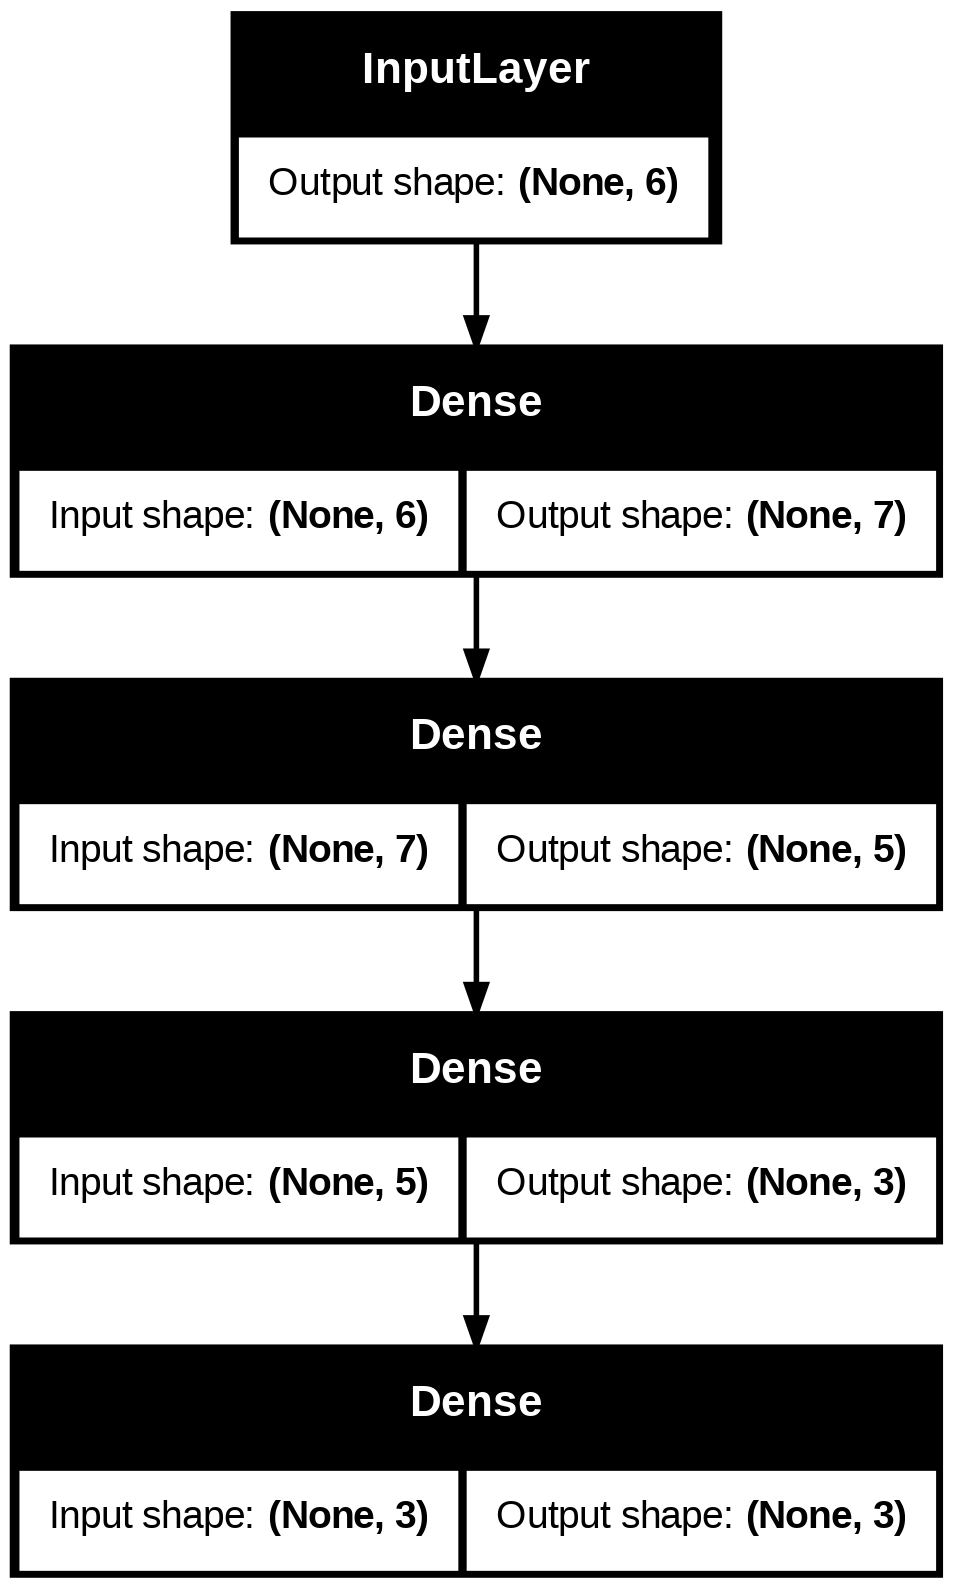

In [41]:
keras.utils.plot_model(model, show_shapes = True)

In [42]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs=100, validation_split=0.1)

scores = model.evaluate(scaled_penguins_x, penguins_y, verbose=2)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.1037 - loss: 1.1494 - val_accuracy: 0.0882 - val_loss: 1.1269
Epoch 2/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0625 - loss: 1.1394

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1873 - loss: 1.1204 - val_accuracy: 0.1765 - val_loss: 1.1079
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2575 - loss: 1.1030 - val_accuracy: 0.2059 - val_loss: 1.0950
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3211 - loss: 1.0902 - val_accuracy: 0.3235 - val_loss: 1.0842
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3579 - loss: 1.0790 - val_accuracy: 0.3824 - val_loss: 1.0743
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4013 - loss: 1.0680 - val_accuracy: 0.3824 - val_loss: 1.0649
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4548 - loss: 1.0579 - val_accuracy: 0.4706 - val_loss: 1.0560
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4816 - loss: 1.0477 - val_accuracy: 0.4706 - val_loss: 1.0471
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5284 - loss: 1.0376 - val_accuracy: 0.4706 - val_loss: 1.0385
Epoc

The model is not calculating any thing really yet. This is because there are Nans in the dataset, so we need to address this. Keras will let you use data that will not work. The model is still not awesome yet. The loss is getting better after removing Nans, so it got a little smart towards the end.

In [45]:
model_logit_false = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model_scaled")

model_logit_false.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_true = model_logit_false.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs = 100, validation_split = 0.1)

scores = model_logit_false.evaluate(scaled_penguins_x, penguins_y, verbose = 2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 3.3727e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 3.5106e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 3.3594e-04
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 3.3259e-04
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 3.2210e-04
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 3.0016e-04
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 2.9628e-04
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0050 - val

Instead of sigmoid, we should use softmax.

In [46]:
model_logit_false.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[9.98661876e-01, 1.33806979e-03, 7.25808693e-12],
       [2.52625964e-13, 9.99942958e-01, 5.69644326e-05],
       [9.99924481e-01, 7.53968779e-05, 7.49061403e-13],
       [8.86689856e-22, 6.16888065e-06, 9.99993742e-01],
       [9.99854803e-01, 1.45308979e-04, 6.79887353e-12],
       [2.29583308e-09, 9.99999821e-01, 7.77425058e-08],
       [9.20125217e-07, 9.99998987e-01, 3.13325632e-09],
       [2.94149740e-16, 5.24542666e-05, 9.99947488e-01],
       [1.46620323e-19, 8.35978062e-06, 9.99991596e-01],
       [4.00301682e-20, 1.87896967e-05, 9.99981105e-01],
       [9.97236013e-01, 2.76380777e-03, 1.53713486e-07],
       [9.99997914e-01, 2.00515888e-06, 4.72213754e-18],
       [9.01190843e-03, 9.90987718e-01, 3.63015573e-07],
       [9.99963105e-01, 3.67907596e-05, 7.64731838e-14],
       [6.06181461e-09, 9.99973714e-01, 2.62423455e-05],
       [9.99884427e-01, 1.15489813e-04, 2.74893021e-12],
       [9.99970973e-01, 2.89112704e-05, 3.27865515e-14],
       [1.93176382e-25, 9.05152

In [47]:
penguins['species']

,species
0,Adelie
1,Chinstrap
2,Adelie
3,Gentoo
4,Adelie
...,...
328,Gentoo
329,Adelie
330,Adelie
331,Chinstrap


In [44]:
penguins_y

array([0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 0, 1,
       0, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2,
       0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0,
       2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1,
       1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 2,